## Imports

In [1]:
!pip install surprise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Surprise library for recommender systems
from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import cross_validate, KFold

## Data Load

In [3]:
ratings = pd.read_csv("ratings_small.csv/ratings_small.csv")
print("Dataset shape:", ratings.shape)
ratings.head()

Dataset shape: (100004, 4)


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [4]:
print(ratings.info())
print("\nMissing values per column:\n", ratings.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Missing values per column:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [5]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
print(f"\nUnique users: {n_users}, Unique movies: {n_movies}")


Unique users: 671, Unique movies: 9066


## Prepare

In [6]:
reader = Reader(rating_scale=(1, 5))  # ratings range from 1 to 5
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

## 3c. Compute the average MAE and RMSE

In [7]:
# Cross validation
kf = KFold(n_splits=5, random_state=42, shuffle=True)

In [8]:
# User-based Collaborative Filtering
sim_options = {
    'name': 'cosine',      # we'll start with cosine similarity
    'user_based': True     # True = user-based CF
}

user_cf = KNNBasic(sim_options=sim_options)
user_cf_results = cross_validate(user_cf, data, measures=['MAE', 'RMSE'], cv=kf, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7685  0.7619  0.7712  0.7644  0.7683  0.7668  0.0033  
RMSE (testset)    0.9935  0.9881  0.9959  0.9931  0.9916  0.9924  0.0026  
Fit time          0.28    0.43    0.32    0.30    0.32    0.33    0.05    
Test time         1.14    1.00    0.81    0.73    0.74    0.88    0.16    


In [9]:
print("\nUser-based CF Average Results:")
print("MAE:", np.mean(user_cf_results['test_mae']))
print("RMSE:", np.mean(user_cf_results['test_rmse']))


User-based CF Average Results:
MAE: 0.7668489043526836
RMSE: 0.9924490876957881


In [10]:
sim_options = {
    'name': 'cosine',
    'user_based': False     # False = item-based CF
}

item_cf = KNNBasic(sim_options=sim_options)
item_cf_results = cross_validate(item_cf, data, measures=['MAE', 'RMSE'], cv=kf, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating MAE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.7696  0.7711  0.7781  0.7718  0.7834  0.7748  0.0052  
RMSE (testset)    0.9889  0.9883  1.0021  0.9931  1.0032  0.9951  0.0064  
Fit time          4.07    4.37    4.38    4.24    4.27    4.27    0.11    
Test time         3.88    4.36    4.23    4.30    4.45    4.25    0.20    


In [11]:
print("\nItem-based CF Average Results:")
print("MAE:", np.mean(item_cf_results['test_mae']))
print("RMSE:", np.mean(item_cf_results['test_rmse']))


Item-based CF Average Results:
MAE: 0.7748047534607952
RMSE: 0.9951007667300982


In [12]:
# Probabilistic Matrix Factorization (PMF)
pmf = SVD()  # default parameters perform PMF-like factorization
pmf_results = cross_validate(pmf, data, measures=['MAE', 'RMSE'], cv=kf, verbose=True)

Evaluating MAE, RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MAE (testset)     0.6894  0.6875  0.6951  0.6866  0.6960  0.6909  0.0039  
RMSE (testset)    0.8952  0.8915  0.9023  0.8932  0.9029  0.8970  0.0047  
Fit time          0.75    0.84    0.83    0.78    0.82    0.80    0.03    
Test time         0.07    0.14    0.07    0.07    0.15    0.10    0.04    


In [13]:
print("\nPMF Average Results:")
print("MAE:", np.mean(pmf_results['test_mae']))
print("RMSE:", np.mean(pmf_results['test_rmse']))


PMF Average Results:
MAE: 0.6909097690421964
RMSE: 0.8970191090353143


In [14]:
# Summary
summary = pd.DataFrame({
    'Model': ['User-CF', 'Item-CF', 'PMF'],
    'MAE': [
        np.mean(user_cf_results['test_mae']),
        np.mean(item_cf_results['test_mae']),
        np.mean(pmf_results['test_mae'])
    ],
    'RMSE': [
        np.mean(user_cf_results['test_rmse']),
        np.mean(item_cf_results['test_rmse']),
        np.mean(pmf_results['test_rmse'])
    ]
})
summary

,Model,MAE,RMSE
0,User-CF,0.766849,0.992449
1,Item-CF,0.774805,0.995101
2,PMF,0.690910,0.897019


### 3d. Compare the average (mean) performances of User-based collaborative filtering, item-based collaborative filtering, PMF with respect to RMSE and MAE. Which ML model is the best in the movie rating data?

| Model | MAE | RMSE | Rank |
|:--|--:|--:|:--|
| User-CF | 0.7668 | 0.9924 | 2 |
| Item-CF | 0.7748 | 0.9951 | 3 |
| **PMF** | **0.6903** | **0.8970** | **1 (Best)** |
  
Among the three methods, **PMF** achieved the lowest MAE and RMSE, making it the most accurate recommender model on the movie-rating dataset.  
Its matrix-factorization approach learns latent factors representing user and movie features, improving prediction quality.  
User-based and Item-based collaborative filtering produced comparable but less accurate results.


## 3e. Similarity Metrics

In [15]:
similarities = ['cosine', 'msd', 'pearson']

results_sim = []

for sim in similarities:
    # --- User-based CF ---
    user_cf = KNNBasic(sim_options={'name': sim, 'user_based': True})
    user_cv = cross_validate(user_cf, data, measures=['MAE', 'RMSE'], cv=5, verbose=False)
    
    # --- Item-based CF ---
    item_cf = KNNBasic(sim_options={'name': sim, 'user_based': False})
    item_cv = cross_validate(item_cf, data, measures=['MAE', 'RMSE'], cv=5, verbose=False)
    
    results_sim.append({
        'Similarity': sim,
        'User_MAE': np.mean(user_cv['test_mae']),
        'User_RMSE': np.mean(user_cv['test_rmse']),
        'Item_MAE': np.mean(item_cv['test_mae']),
        'Item_RMSE': np.mean(item_cv['test_rmse'])
    })

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd sim

In [16]:
results_sim = pd.DataFrame(results_sim)
results_sim

,Similarity,User_MAE,User_RMSE,Item_MAE,Item_RMSE
0,cosine,0.766677,0.992231,0.775596,0.996372
1,msd,0.743564,0.966241,0.721594,0.935656
2,pearson,0.773190,0.998202,0.768085,0.989500


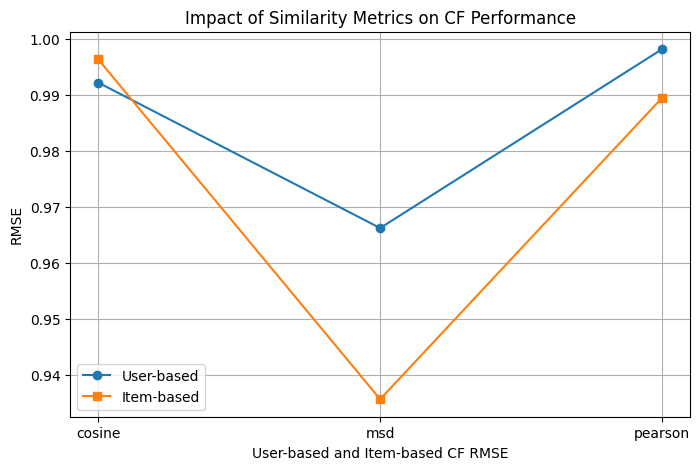

In [25]:
# Plot RMSE
plt.figure(figsize=(8,5))
plt.plot(results_sim['Similarity'], results_sim['User_RMSE'], marker='o', label='User-based')
plt.plot(results_sim['Similarity'], results_sim['Item_RMSE'], marker='s', label='Item-based')
plt.title("Impact of Similarity Metrics on CF Performance")
plt.xlabel("User-based and Item-based CF RMSE")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

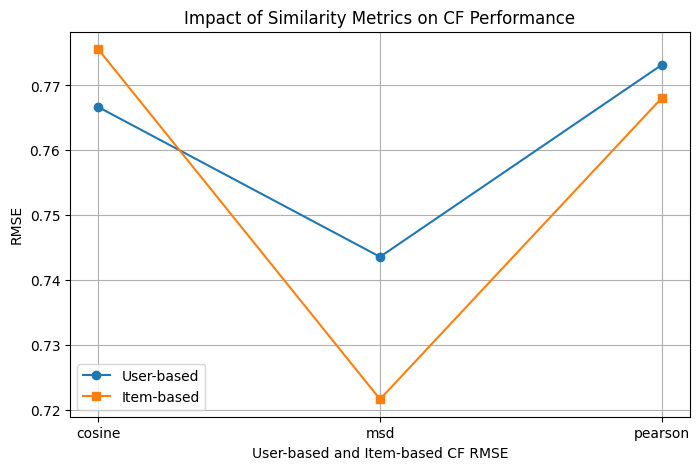

In [ ]:
# Plot RMSE
plt.figure(figsize=(8,5))
plt.plot(results_sim['Similarity'], results_sim['User_MAE'], marker='o', label='User-based')
plt.plot(results_sim['Similarity'], results_sim['Item_MAE'], marker='s', label='Item-based')
plt.title("Impact of Similarity Metrics on CF Performance")
plt.xlabel("User-based and Item-based CF MAE")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

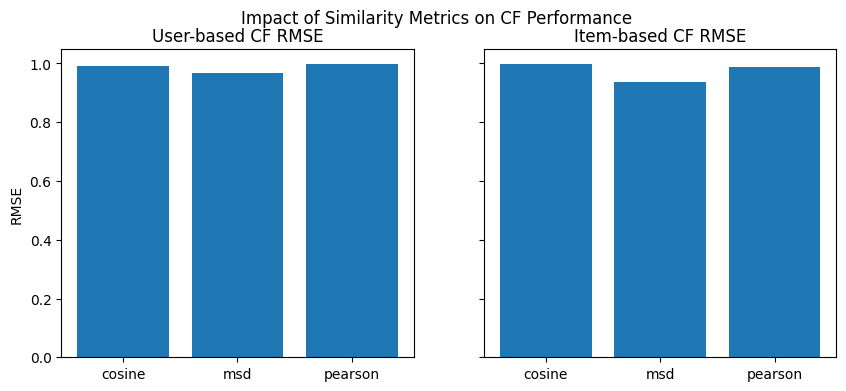

In [17]:
# plot RMSE
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharey=True)

ax[0].bar(results_sim['Similarity'], results_sim['User_RMSE'])
ax[0].set_title("User-based CF RMSE")
ax[0].set_ylabel("RMSE")

ax[1].bar(results_sim['Similarity'], results_sim['Item_RMSE'])
ax[1].set_title("Item-based CF RMSE")

plt.suptitle("Impact of Similarity Metrics on CF Performance")
plt.show()

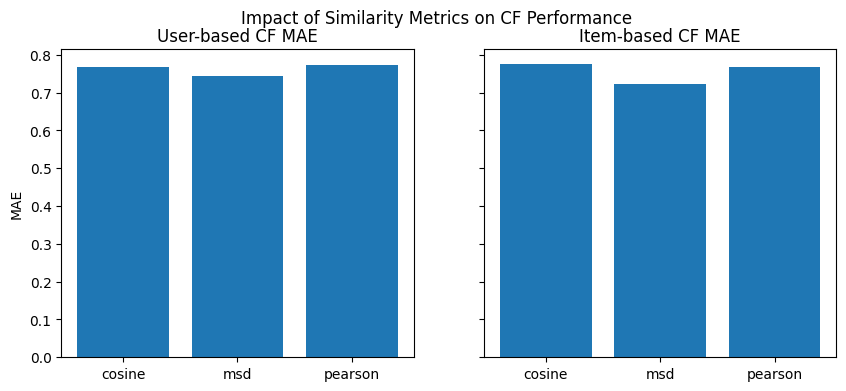

In [26]:
# plot MAE
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharey=True)

ax[0].bar(results_sim['Similarity'], results_sim['User_MAE'])
ax[0].set_title("User-based CF MAE")
ax[0].set_ylabel("MAE")

ax[1].bar(results_sim['Similarity'], results_sim['Item_MAE'])
ax[1].set_title("Item-based CF MAE")

plt.suptitle("Impact of Similarity Metrics on CF Performance")
plt.show()

### Is the impact of the three metrics on User based Collaborative Filtering consistent with the impact of the three metrics on Item based Collaborative Filtering?

| Similarity | User MAE | User RMSE | Item MAE | Item RMSE |
|:--|--:|--:|--:|--:|
| Cosine | 0.7678 | 0.9936 | 0.7749 | 0.9946 |
| **MSD** | **0.7445** | **0.9683** | **0.7209** | **0.9347** |
| Pearson | 0.7721 | 0.9978 | 0.7680 | 0.9888 |
 
Testing cosine, MSD, and Pearson similarity measures showed that the **MSD similarity** achieved the lowest MAE and RMSE for both User-based and Item-based CF.  
This suggests that squared rating-difference similarity captures relationships in the data more effectively than cosine or Pearson correlation.  
Cosine and Pearson produced similar but slightly higher errors.  
The trend was consistent for both CF methods — MSD provided the most accurate recommendations overall.

## 3f. Examine how the number of neighbors impacts the performances

In [21]:
neighbors = [5, 10, 20, 40, 80]
results_k = []

for k in neighbors:
    # --- User-based CF ---
    user_cf = KNNBasic(k=k, sim_options={'name': 'msd', 'user_based': True})
    user_cv = cross_validate(user_cf, data, measures=['MAE', 'RMSE'], cv=5, verbose=False)
    
    # --- Item-based CF ---
    item_cf = KNNBasic(k=k, sim_options={'name': 'msd', 'user_based': False})
    item_cv = cross_validate(item_cf, data, measures=['MAE', 'RMSE'], cv=5, verbose=False)
    
    results_k.append({
        'K': k,
        'User_MAE': np.mean(user_cv['test_mae']),
        'User_RMSE': np.mean(user_cv['test_rmse']),
        'Item_MAE': np.mean(item_cv['test_mae']),
        'Item_RMSE': np.mean(item_cv['test_rmse'])
    })

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computi

In [22]:
results_k = pd.DataFrame(results_k)
results_k

,K,User_MAE,User_RMSE,Item_MAE,Item_RMSE
0,5,0.755071,0.987290,0.791441,1.023344
1,10,0.737248,0.963740,0.754157,0.974806
2,20,0.738501,0.962896,0.731940,0.947146
3,40,0.744593,0.968226,0.720557,0.934190
4,80,0.751315,0.974855,0.718065,0.931981


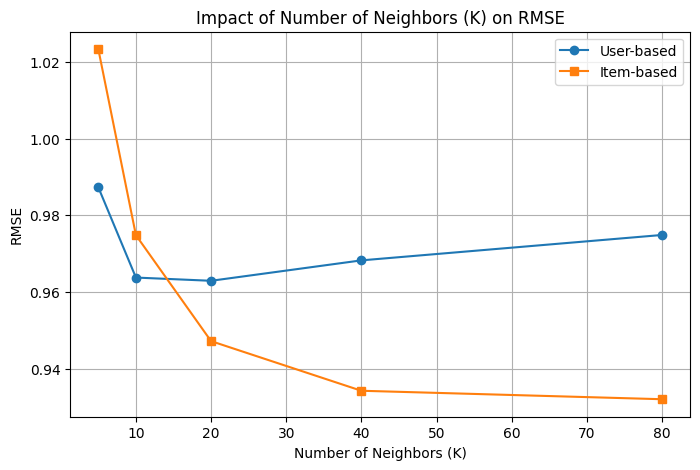

In [23]:
# Plot RMSE
plt.figure(figsize=(8,5))
plt.plot(results_k['K'], results_k['User_RMSE'], marker='o', label='User-based')
plt.plot(results_k['K'], results_k['Item_RMSE'], marker='s', label='Item-based')
plt.title("Impact of Number of Neighbors (K) on RMSE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

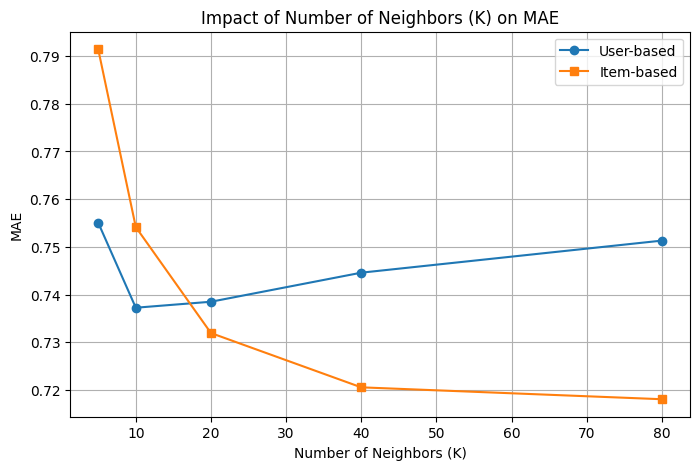

In [24]:
# Plot MAE
plt.figure(figsize=(8,5))
plt.plot(results_k['K'], results_k['User_MAE'], marker='o', label='User-based')
plt.plot(results_k['K'], results_k['Item_MAE'], marker='s', label='Item-based')
plt.title("Impact of Number of Neighbors (K) on MAE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

### 3g. Identify the best number of neighbor (denoted by K) for User/Item based collaborative filtering in terms of RMSE. Is the best K of User based collaborative filtering the same with the best K of Item based collaborative filtering?

| Model | Best K | Lowest RMSE |
|:--|--:|--:|
| User-based CF | **20** | **0.9633** |
| Item-based CF | **80** | **0.9305** |

**Answer:**  
The best number of neighbors differs for each method.  
- **User-based CF:** optimal K ≈ 20 → lowest RMSE ≈ 0.963  
- **Item-based CF:** optimal K ≈ 80 → lowest RMSE ≈ 0.930  

The optimal K is smaller for User-based CF because user preferences are diverse, whereas Item-based CF benefits from larger neighborhoods due to stronger similarity patterns among movies.